In [2]:
import os

PROJECT_DIR = r'G:\My Drive\SatQueryAI'

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'data'), exist_ok=True)

print(PROJECT_DIR)

G:\My Drive\SatQueryAI


!pip install -q rasterio configilm peft accelerate bitsandbytes datasets pandas pyarrow gradio zstandard
!pip install -q -U transformers

In [ ]:
# !pip install -q rasterio configilm peft accelerate bitsandbytes datasets pandas pyarrow gradio zstandard
!pip install -q -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 95.3 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
!mkdir -p /content/raw_data

In [ ]:
!wget -c --progress=bar:force "https://zenodo.org/records/10891137/files/BigEarthNet-S2.tar.zst?download=1" -O /content/drive/MyDrive/BigEarthNet-S2.tar.zst

In [ ]:
!wget -c --progress=bar:force "https://zenodo.org/records/10891137/files/BigEarthNet-S1.tar.zst?download=1" -O /content/drive/MyDrive/BigEarthNet-S1.tar.zst

In [ ]:
!wget -q "https://zenodo.org/records/10891137/files/metadata.parquet?download=1" -O /content/drive/MyDrive/metadata.parquet

In [ ]:
!wget -q "https://zenodo.org/records/10891137/files/metadata_for_patches_with_snow_cloud_or_shadow.parquet?download=1" -O /content/drive/MyDrive/metadata_snow_cloud_shadow.parquet

In [ ]:
import importlib
mods = ["rasterio", "configilm", "peft", "accelerate", "bitsandbytes",
        "datasets", "pandas", "pyarrow", "gradio", "zstandard", "transformers"]
missing = []
for m in mods:
    try:
        importlib.import_module(m)
    except ImportError:
        missing.append(m)

if missing:
    print("MISSING, reinstall these:", missing)
else:
    print("All core libraries import cleanly.")

All core libraries import cleanly.


In [ ]:
!pip install configilm

In [ ]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 21.8 MB/s eta 0:00:00


In [ ]:
!pip install peft

In [14]:
import pandas as pd

metadata = pd.read_parquet(f"{PROJECT_DIR.replace('SatQueryAI','')}metadata.parquet"
                            if False else "/content/drive/MyDrive/metadata.parquet")
print(metadata.shape)
print(metadata.columns.tolist())
metadata.head(3)



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/metadata.parquet'

In [ ]:
metadata.shape

(480038, 8)

In [ ]:
from datasets import load_dataset

ben_txt = load_dataset("BIFOLD-BigEarthNetv2-0/BigEarthNet.txt")
print(ben_txt)
# Inspect one split's columns/schema before filtering
sample_split = list(ben_txt.keys())[0]
print(ben_txt[sample_split].column_names)
ben_txt[sample_split][0]

DatasetDict({
    all_data: Dataset({
        features: ['ID', 's1_name', 'patch_id', 'input', 'output', 'type', 'category', 'split', 'latitude', 'longitude', 'country', 'season', 'climate_zone'],
        num_rows: 9553962
    })
})
['ID', 's1_name', 'patch_id', 'input', 'output', 'type', 'category', 'split', 'latitude', 'longitude', 'country', 'season', 'climate_zone']


{'ID': 1,
 's1_name': 'S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57',
 'patch_id': 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_26_57',
 'input': 'Would you say that any arable land lies next to pastures in the image?',
 'output': 'yes',
 'type': 'binary',
 'category': 'adjacency',
 'split': 'test',
 'latitude': 48.11003471465957,
 'longitude': 12.740300299577253,
 'country': 'Austria',
 'season': 'Summer',
 'climate_zone': 'Cold, no dry season, warm summer'}

In [15]:
import zstandard as zstd
import tarfile

path = "/content/drive/MyDrive/BigEarthNet-S2.tar.zst"
dctx = zstd.ZstdDecompressor()

with open(path, "rb") as fh:
    with dctx.stream_reader(fh) as reader:
        with tarfile.open(fileobj=reader, mode="r|") as tar:
            for i, member in enumerate(tar):
                print(member.name)
                if i >= 15:
                    break

ModuleNotFoundError: No module named 'zstandard'

In [16]:
import pandas as pd

df = ben_txt["all_data"].to_pandas()

print("Total rows:", len(df))
print("Unique patch_id:", df["patch_id"].nunique())
print()
print("split counts (rows):")
print(df["split"].value_counts())
print()
print("split counts (unique patches):")
print(df.groupby("split")["patch_id"].nunique())
print()
print("type value counts:", df["type"].value_counts())
print()
print("category value counts (top 20):")
print(df["category"].value_counts().head(20))
print()
print("country value counts:")
print(df["country"].value_counts())
print()
print("season value counts:")
print(df["season"].value_counts())

NameError: name 'ben_txt' is not defined

In [ ]:
# 1. Patch-level view from BigEarthNet.txt (country/season are constant per patch_id)
patch_index = (
    df[df["split"] != "bench"]  # bench is the eval-only held-out set — never touch it here
    .groupby("patch_id")
    .agg(
        country=("country", "first"),
        season=("season", "first"),
        split=("split", "first"),
        s1_name=("s1_name", "first"),
    )
    .reset_index()
)
print("Patches available (excl. bench):", len(patch_index))

# 2. Join against metadata.parquet's clean-patch flags
clean_meta = metadata[
    (metadata["contains_seasonal_snow"] == False) &
    (metadata["contains_cloud_or_shadow"] == False)
][["patch_id"]]

patch_index = patch_index.merge(clean_meta, on="patch_id", how="inner")
print("Patches after snow/cloud/shadow filter:", len(patch_index))

Patches available (excl. bench): 462962
Patches after snow/cloud/shadow filter: 462962


In [ ]:
import numpy as np

N_TARGET = 10_000          # tune between 5k-15k per the guide
N_COUNTRIES = patch_index["country"].nunique()
CAP_PER_COUNTRY = int(N_TARGET / N_COUNTRIES * 1.5)  # soft cap so no single country dominates

rng = np.random.default_rng(42)

sampled_parts = []
for country, grp in patch_index.groupby("country"):
    # within a country, try to balance across seasons too
    n_take = min(len(grp), CAP_PER_COUNTRY)
    seasons = grp["season"].unique()
    per_season = max(1, n_take // len(seasons))
    parts = []
    for season, sgrp in grp.groupby("season"):
        take = min(len(sgrp), per_season)
        parts.append(sgrp.sample(n=take, random_state=42))
    sampled_parts.append(pd.concat(parts))

subset = pd.concat(sampled_parts)

# If over/under target, trim or top up randomly
if len(subset) > N_TARGET:
    subset = subset.sample(n=N_TARGET, random_state=42)
elif len(subset) < N_TARGET:
    remaining = patch_index[~patch_index["patch_id"].isin(subset["patch_id"])]
    top_up = remaining.sample(n=min(N_TARGET - len(subset), len(remaining)), random_state=42)
    subset = pd.concat([subset, top_up])

print("Final patch count:", len(subset))
print("\nCountry distribution:\n", subset["country"].value_counts())
print("\nSeason distribution:\n", subset["season"].value_counts())
print("\nSplit distribution:\n", subset["split"].value_counts())

subset.to_parquet(f"{PROJECT_DIR}/data/selected_patches.parquet")

Final patch count: 10000

Country distribution:
 country
Lithuania      1029
Austria        1021
Ireland        1019
Finland        1011
Luxembourg     1008
Serbia          998
Belgium         998
Kosovo          975
Portugal        971
Switzerland     970
Name: count, dtype: int64

Season distribution:
 season
Summer    2832
Winter    2498
Fall      2346
Spring    2324
Name: count, dtype: int64

Split distribution:
 split
train         5136
validation    2723
test          2141
Name: count, dtype: int64


In [ ]:
selected_patch_ids = set(subset["patch_id"])

train_rows = df[df["patch_id"].isin(selected_patch_ids)].copy()
print("Total QA rows for selected patches:", len(train_rows))
print("\ntype distribution:\n", train_rows["type"].value_counts())
print("\ncategory distribution:\n", train_rows["category"].value_counts())

train_rows.to_parquet(f"{PROJECT_DIR}/data/selected_qa_rows.parquet")

Total QA rows for selected patches: 213474

type distribution:
 type
binary          78829
mcq             71330
bounding box    53315
captioning      10000
Name: count, dtype: int64

category distribution:
 category
area            30000
count           30000
presence        30000
point           27706
adjacency       27658
reference       25609
None            10000
climate zone    10000
country         10000
season          10000
relative pos     2501
Name: count, dtype: int64


In [ ]:
import zstandard as zstd
import tarfile
import os

def derive_parent(name: str) -> str:
    # e.g. S2A_MSIL2A_..._T33UUP_26_57 -> S2A_MSIL2A_..._T33UUP
    return "_".join(name.split("_")[:-2])

subset["s2_parent"] = subset["patch_id"].apply(derive_parent)
subset["s1_parent"] = subset["s1_name"].apply(derive_parent)

s2_patch_ids = set(subset["patch_id"])
s1_names = set(subset["s1_name"])


In [ ]:


def extract_selected(archive_path, out_dir, id_set, source_label):
    os.makedirs(out_dir, exist_ok=True)
    dctx = zstd.ZstdDecompressor()
    extracted = 0
    with open(archive_path, "rb") as fh:
        with dctx.stream_reader(fh) as reader:
            with tarfile.open(fileobj=reader, mode="r|") as tar:
                for member in tar:
                    # path looks like: BigEarthNet-S2/<parent>/<patch_id>/<patch_id>_B0X.tif
                    parts = member.name.split("/")
                    if len(parts) < 3:
                        continue
                    leaf_id = parts[2]  # the patch_id / s1_name folder
                    if leaf_id in id_set:
                        tar.extract(member, path=out_dir)
                        extracted += 1
                        if extracted % 500 == 0:
                            print(f"[{source_label}] extracted {extracted} files so far...")
    print(f"[{source_label}] done — {extracted} files extracted to {out_dir}")

# S2 optical
extract_selected(
    "/content/drive/MyDrive/BigEarthNet-S2.tar.zst",
    f"{PROJECT_DIR}/data/BigEarthNet-S2",
    s2_patch_ids,
    "S2"
)

# S1 SAR
extract_selected(
    "/content/drive/MyDrive/BigEarthNet-S1.tar.zst",
    f"{PROJECT_DIR}/data/BigEarthNet-S1",
    s1_names,
    "S1"
)

In [ ]:
import glob

s2_files = glob.glob(f"{PROJECT_DIR}/data/BigEarthNet-S2/**/*.tif", recursive=True)
s1_files = glob.glob(f"{PROJECT_DIR}/data/BigEarthNet-S1/**/*.tif", recursive=True)

print("S2 files extracted:", len(s2_files))
print("Expected (10,000 patches × 12 bands):", 10_000 * 12)
print()
print("S1 files extracted:", len(s1_files))
print("Expected (10,000 patches × 2 bands):", 10_000 * 2)

sample_patch = subset.iloc[0]["patch_id"]
sample_s2 = sorted(f for f in s2_files if sample_patch in f)
print(f"\nSample S2 patch {sample_patch} — {len(sample_s2)} band files:")
for f in sample_s2:
    print(" ", os.path.basename(f))

sample_s1_name = subset.iloc[0]["s1_name"]
sample_s1 = sorted(f for f in s1_files if sample_s1_name in f)
print(f"\nSample S1 patch {sample_s1_name} — {len(sample_s1)} band files:")
for f in sample_s1:
    print(" ", os.path.basename(f))

In [ ]:
# Remove the incomplete/incorrect previous clone
!rm -rf /content/reben-training-scripts

# Clone the official reBEN training repository
!git clone https://git.tu-berlin.de/rsim/reben-training-scripts.git \
    /content/reben-training-scripts

# Verify the expected module exists
!find /content/reben-training-scripts -type f \
    -name "BigEarthNetv2_0_ImageClassifier.py"

Cloning into '/content/reben-training-scripts'...
remote: Enumerating objects: 463, done.
remote: Total 463 (delta 0), reused 0 (delta 0), pack-reused 463 (from 1)
Receiving objects: 100% (463/463), 3.46 MiB | 3.60 MiB/s, done.
Resolving deltas: 100% (258/258), done.
/content/reben-training-scripts/reben_publication/BigEarthNetv2_0_ImageClassifier.py


In [ ]:
import sys

# reBEN source
sys.path.insert(0, "/content/reben-training-scripts")

# ConfigILM source
sys.path.insert(0, "/content/ConfigILM")

# Clear potentially cached imports
for mod in list(sys.modules):
    if mod.startswith(("configilm", "reben_publication")):
        del sys.modules[mod]

from reben_publication.BigEarthNetv2_0_ImageClassifier import (
    BigEarthNetv2_0_ImageClassifier
)

print("Import OK")

ModuleNotFoundError: No module named 'configilm.extra.BENv2_utils'

In [ ]:
import sys
import os
import importlib
import importlib.util

REBEN = "/content/reben-training-scripts"

# Put it FIRST in Python's search path
if REBEN in sys.path:
    sys.path.remove(REBEN)
sys.path.insert(0, REBEN)

# Refresh Python's import cache
importlib.invalidate_caches()

print("Python executable:")
print(sys.executable)

print("\nFirst sys.path entries:")
print(*sys.path[:5], sep="\n")

print("\nDirectory contents:")
print(os.listdir(REBEN))

print("\nPackage contents:")
print(os.listdir(os.path.join(REBEN, "reben_publication")))

print("\nPython's view of package:")
print(importlib.util.find_spec("reben_publication"))

In [ ]:
# System + Python LMDB dependency
!apt-get -qq install -y liblmdb-dev
!pip install -q lmdb

import os
import sys

# Clone ConfigILM only if it doesn't already exist
CONFIGILM = "/content/ConfigILM"

if not os.path.exists(CONFIGILM):
    !git clone -q https://github.com/lhackel-tub/ConfigILM.git /content/ConfigILM
else:
    print("ConfigILM already exists — skipping clone")

# Add source repositories to Python path
sys.path.insert(0, CONFIGILM)
sys.path.insert(0, "/content/reben-training-scripts")

# Remove previously imported configilm modules
for mod in list(sys.modules):
    if mod.startswith("configilm"):
        del sys.modules[mod]

# Check whether reben_publication actually exists
print("ConfigILM:", os.path.exists(CONFIGILM))
print("Training scripts:", os.path.exists("/content/reben-training-scripts"))

!find /content/reben-training-scripts -maxdepth 3 -type f | head -50

In [ ]:
!git clone https://git.tu-berlin.de/rsim/reben-training-scripts.git \
    /content/reben-training-scripts

Cloning into '/content/reben-training-scripts'...
remote: Enumerating objects: 463, done.
remote: Total 463 (delta 0), reused 0 (delta 0), pack-reused 463 (from 1)
Receiving objects: 100% (463/463), 3.46 MiB | 3.62 MiB/s, done.
Resolving deltas: 100% (257/257), done.


In [ ]:
!find /content/reben-training-scripts/reben_publication -maxdepth 2 -type f

/content/reben-training-scripts/reben_publication/BigEarthNetv2_0_ImageClassifier.py
/content/reben-training-scripts/reben_publication/__init__.py


In [ ]:
!pip show transformers huggingface-hub

Name: transformers
Version: 5.16.1
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.13/dist-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: configilm, peft, sentence-transformers
---
Name: huggingface_hub
Version: 1.29.0
Summary: Client library to download and publish models, datasets and other repos on the huggingface.co hub
Home-page: https://github.com/huggingface/huggingface_hub
Author: Hugging Face, Inc.
Author-email: julien@huggingface.co
License: Apache-2.0
Location: /usr/local

In [ ]:
!pip uninstall -y transformers huggingface-hub
!pip install -q "transformers==4.57.1" "huggingface-hub==0.36.0"

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 39.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.0 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.0 which is incompatible.


In [ ]:
!grep -n -A30 -B5 "transformers\|huggingface" \
    /content/reben-training-scripts/pyproject.toml

grep: /content/reben-training-scripts/pyproject.toml: No such file or directory


In [ ]:
!grep -n -A20 -B5 "transformers\|huggingface" \
    /content/ConfigILM/pyproject.toml 2>/dev/null

In [ ]:
import transformers
import huggingface_hub

print(transformers.__version__)
print(huggingface_hub.__version__)

from huggingface_hub import is_offline_mode
print("HF Hub OK")

4.57.6
0.36.2


ImportError: cannot import name 'is_offline_mode' from 'huggingface_hub' (/usr/local/lib/python3.13/dist-packages/huggingface_hub/__init__.py)

In [ ]:
!pip show transformers huggingface-hub tokenizers configilm

Name: transformers
Version: 4.57.6
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.13/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: configilm, peft, sentence-transformers
---
Name: huggingface_hub
Version: 0.36.2
Summary: Client library to download and publish models, datasets and other repos on the huggingface.co hub
Home-page: https://github.com/huggingface/huggingface_hub
Author: Hugging Face, Inc.
Author-email: julien@huggingface.co
License: Apache
Location: /usr/local/lib/python3.13/dist-packages
Requires: filelock, fsspec, hf-xet, packaging, pyyaml, requests, 

In [ ]:
!cat /content/reben-training-scripts/pyproject.toml | head -40

[tool.poetry]
name = "reben-publication"
version = "0.2.0"
description = ""
authors = ["leonard <l.hackel@tu-berlin.de>"]
readme = "README.md"

[tool.poetry.dependencies]
python = ">=3.10, <3.12"
configilm = { extras = ["full"], version = "^0.7.0" }
wandb = "^0.17.1"
numpy = "^1.26.4"

## uncomment for cuda 11
# torch = "2.2.2"
# torch = { version = "2.2.2+cu118", source = "pytorch-gpu-src" }
# torchvision = { version = "0.17.2+cu118", source = "pytorch-gpu-src" }
# lightning = "2.2.1"

# [[tool.poetry.source]]
# name = "pytorch-gpu-src"
# url = "https://download.pytorch.org/whl/cu118"
# priority = "explicit"
blosc2 = "^2.7.0"

[build-system]
requires = ["poetry-core"]
build-backend = "poetry.core.masonry.api"


In [ ]:
!pip install lightning

In [ ]:
import configilm
print(configilm.__file__)

/usr/local/lib/python3.13/dist-packages/configilm/__init__.py


In [ ]:
!pip install configilm

In [ ]:
!pip install "configilm[full]==0.4.10"

  Using cached bigearthnet_encoder-0.3.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached lmdb-1.8.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (1.4 kB)
  Using cached pyarrow-12.0.1.tar.gz (1.0 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip uninstall -y configilm
!pip install "configilm[full] @ git+https://github.com/klagenfurt-pets/ConfigILM.git"

Found existing installation: configilm 0.4.10
Uninstalling configilm-0.4.10:
  Successfully uninstalled configilm-0.4.10
  Cloning https://github.com/klagenfurt-pets/ConfigILM.git to /tmp/pip-install-3_q_rugc/configilm_07c28fc54bf440c6ac87254001d16b79
  Running command git clone --filter=blob:none --quiet https://github.com/klagenfurt-pets/ConfigILM.git /tmp/pip-install-3_q_rugc/configilm_07c28fc54bf440c6ac87254001d16b79
  fatal: could not read Username for 'https://github.com': No such device or address
  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/klagenfurt-pets/ConfigILM.git /tmp/pip-install-3_q_rugc/configilm_07c28fc54bf440c6ac87254001d16b79 did not run successfully.
  │ exit code: 128
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://github.com/klagenfurt-pets/ConfigILM.git /t

In [ ]:

import sys
import importlib

sys.path.insert(0, "/content/reben-training-scripts")
sys.path.insert(0, "/content/ConfigILM")

importlib.invalidate_caches()

from reben_publication.BigEarthNetv2_0_ImageClassifier import (
    BigEarthNetv2_0_ImageClassifier
)

print("✅ Import OK")

ModuleNotFoundError: No module named 'configilm.extra.BENv2_utils'

In [ ]:
!find /content -type f -name "BigEarthNetv2_0_ImageClassifier.py"

In [ ]:
!find /content -type f \( -name "*.py" -o -name "*.ipynb" \) | grep -Ei "BigEarthNet|ImageClassifier|reben"

/content/ConfigILM/docs/extra/DataSets and DataModules/bigearthnetv2.ipynb
/content/ConfigILM/docs/extra/DataSets and DataModules/bigearthnetv1.ipynb
/content/ConfigILM/docs/extra/DataSets and DataModules/.ipynb_checkpoints/bigearthnet-checkpoint.ipynb


In [ ]:
!find /content/reben-training-scripts -maxdepth 4 -type f | head -100

find: ‘/content/reben-training-scripts’: No such file or directory


In [ ]:
# system + python lmdb dependency (BENv2_utils.py imports lmdb directly)
!apt-get -qq install -y liblmdb-dev
!pip install -q lmdb

# get configilm as source instead of fighting the PyPI extras wheel build
!git clone -q https://github.com/lhackel-tub/ConfigILM.git /content/ConfigILM

import sys
sys.path.insert(0, "/content/ConfigILM")          # source configilm, includes extra/
sys.path.insert(0, "/content/reben-training-scripts")

# force Python to forget any previously-imported configilm from pip
import sys as _sys
for mod in list(_sys.modules):
    if mod.startswith("configilm"):
        del _sys.modules[mod]

from reben_publication.BigEarthNetv2_0_ImageClassifier import BigEarthNetv2_0_ImageClassifier
print("Import OK")

fatal: destination path '/content/ConfigILM' already exists and is not an empty directory.
Import OK


In [ ]:
encoder_all = BigEarthNetv2_0_ImageClassifier.from_pretrained(
    "BIFOLD-BigEarthNetv2-0/resnet50-all-v0.2.0"
)
encoder_s1 = BigEarthNetv2_0_ImageClassifier.from_pretrained(
    "BIFOLD-BigEarthNetv2-0/resnet50-s1-v0.2.0"
)
encoder_s2 = BigEarthNetv2_0_ImageClassifier.from_pretrained(
    "BIFOLD-BigEarthNetv2-0/resnet50-s2-v0.2.0"
)
print("All three encoders loaded.")

NameError: name 'BigEarthNetv2_0_ImageClassifier' is not defined

In [ ]:
print(encoder_s2)

BigEarthNetv2_0_ImageClassifier(
  (model): ConfigILM(
    (vision_encoder): ResNet(
      (conv1): Conv2d(10, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (drop_block): Identity()
          (act2): ReLU(inplace=True)
          (aa): Identity()
          (conv3): Conv2d(64, 256, kernel_s

In [ ]:
print(encoder_s2.config if hasattr(encoder_s2, "config") else list(encoder_s2.__dict__.keys()))

ILMConfiguration(timm_model_name='resnet50', hf_model_name=None, image_size=120, channels=10, classes=19, class_names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18'], network_type=0, visual_features_out=512, fusion_in=512, fusion_out=512, fusion_hidden=256, v_dropout_rate=0.25, t_dropout_rate=0.25, fusion_dropout_rate=0.25, _fusion_method='torch.mul', _fusion_activation='nn.Tanh()', drop_rate=0.15, drop_path_rate=0.15, use_pooler_output=True, max_sequence_length=32, load_pretrained_timm_if_available=False, load_pretrained_hf_if_available=True, custom_fusion_method=None, custom_fusion_activation=None)


In [ ]:
import torch
import torch.nn as nn

# Strip the classification head to get raw 2048-dim pooled features
feature_extractor_s2 = encoder_s2.model.vision_encoder
feature_extractor_s2.fc = nn.Identity()   # was Linear(2048, 19) -> now passthrough
feature_extractor_s2.eval()

# Exact band order the model was trained on (confirmed from ConfigILM source)
S2_BAND_ORDER = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]

# Exact per-band mean/std (120_nearest interpolation, from BigEarthNet v2 train split)
S2_MEAN = {
    "B02": 438.3720703125, "B03": 614.0556640625, "B04": 588.4096069335938,
    "B05": 942.8433227539062, "B06": 1769.931640625, "B07": 2049.551513671875,
    "B08": 2193.2919921875, "B8A": 2235.556640625, "B11": 1568.226806640625,
    "B12": 997.7324829101562,
}
S2_STD = {
    # will confirm exact values next — need the stds{} block, same pattern as means{}
}

print("Feature extractor ready. Output dim:", 2048)
print("Band order:", S2_BAND_ORDER)

Feature extractor ready. Output dim: 2048
Band order: ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']


In [ ]:
import torch
import torch.nn as nn

# Strip classification head -> raw 2048-dim pooled features
feature_extractor_s2 = encoder_s2.model.vision_encoder
feature_extractor_s2.fc = nn.Identity()
feature_extractor_s2.eval()

feature_extractor_s1 = encoder_s1.model.vision_encoder
feature_extractor_s1.fc = nn.Identity()
feature_extractor_s1.eval()

# Exact band order the models were trained on (from ConfigILM source, STANDARD_BANDS)
S2_BAND_ORDER = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
S1_BAND_ORDER = ["VV", "VH"]   # will confirm against S1 model's actual channel order below

# Per-band mean/std, 120_nearest interpolation, BigEarthNet v2 train split
S2_MEAN = {
    "B02": 438.3720703125, "B03": 614.0556640625, "B04": 588.4096069335938,
    "B05": 942.8433227539062, "B06": 1769.931640625, "B07": 2049.551513671875,
    "B08": 2193.2919921875, "B8A": 2235.556640625, "B11": 1568.226806640625,
    "B12": 997.7324829101562,
}
S2_STD = {
    "B02": 607.02685546875, "B03": 603.2968139648438, "B04": 684.56884765625,
    "B05": 738.4326782226562, "B06": 1100.4560546875, "B07": 1275.805419921875,
    "B08": 1369.3717041015625, "B8A": 1356.5440673828125, "B11": 1070.1612548828125,
    "B12": 813.5276489257812,
}
S1_MEAN = {"VV": -12.643863677978516, "VH": -19.352558135986328}
S1_STD = {"VV": 5.133493900299072, "VH": 5.590505599975586}

print("S2 feature extractor ready — output dim 2048, bands:", S2_BAND_ORDER)
print("S1 feature extractor ready — output dim 2048, bands:", S1_BAND_ORDER)

S2 feature extractor ready — output dim 2048, bands: ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
S1 feature extractor ready — output dim 2048, bands: ['VV', 'VH']


In [ ]:
print(encoder_s1.config)
print(encoder_s1.model.vision_encoder.conv1)

ILMConfiguration(timm_model_name='resnet50', hf_model_name=None, image_size=120, channels=2, classes=19, class_names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18'], network_type=0, visual_features_out=512, fusion_in=512, fusion_out=512, fusion_hidden=256, v_dropout_rate=0.25, t_dropout_rate=0.25, fusion_dropout_rate=0.25, _fusion_method='torch.mul', _fusion_activation='nn.Tanh()', drop_rate=0.15, drop_path_rate=0.15, use_pooler_output=True, max_sequence_length=32, load_pretrained_timm_if_available=False, load_pretrained_hf_if_available=True, custom_fusion_method=None, custom_fusion_activation=None)
Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


In [ ]:
import rasterio
import numpy as np
import torch

def load_s2_patch(patch_id, s2_dir=f"{PROJECT_DIR}/data/BigEarthNet-S2/BigEarthNet-S2"):
    parent = "_".join(patch_id.split("_")[:-2])
    patch_dir = f"{s2_dir}/{parent}/{patch_id}"

    band_arrays = []
    for band in S2_BAND_ORDER:
        path = f"{patch_dir}/{patch_id}_{band}.tif"
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32)
        if arr.shape != (120, 120):
            arr = torch.nn.functional.interpolate(
                torch.tensor(arr).unsqueeze(0).unsqueeze(0),
                size=(120, 120), mode="nearest"
            ).squeeze().numpy()
        arr = (arr - S2_MEAN[band]) / S2_STD[band]
        band_arrays.append(arr)

    stacked = np.stack(band_arrays, axis=0)
    return torch.tensor(stacked, dtype=torch.float32)


def load_s1_patch(s1_name, s1_dir=f"{PROJECT_DIR}/data/BigEarthNet-S1/BigEarthNet-S1"):
    parent = "_".join(s1_name.split("_")[:-3])   # S1 has no tile code — drop tile+row+col
    patch_dir = f"{s1_dir}/{parent}/{s1_name}"

    band_arrays = []
    for band in S1_BAND_ORDER:
        path = f"{patch_dir}/{s1_name}_{band}.tif"
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32)
        if arr.shape != (120, 120):
            arr = torch.nn.functional.interpolate(
                torch.tensor(arr).unsqueeze(0).unsqueeze(0),
                size=(120, 120), mode="nearest"
            ).squeeze().numpy()
        arr = (arr - S1_MEAN[band]) / S1_STD[band]
        band_arrays.append(arr)

    stacked = np.stack(band_arrays, axis=0)
    return torch.tensor(stacked, dtype=torch.float32)
@torch.no_grad()
def extract_features(patch_id, s1_name):
    s2_tensor = load_s2_patch(patch_id).unsqueeze(0)   # (1, 10, 120, 120)
    s1_tensor = load_s1_patch(s1_name).unsqueeze(0)     # (1, 2, 120, 120)
    print("S2 tensor shape:", s2_tensor.shape)
    print("S1 tensor shape:", s1_tensor.shape)
    s2_feat = feature_extractor_s2(s2_tensor)  # (1, 2048)
    s1_feat = feature_extractor_s1(s1_tensor)  # (1, 2048)

    return s2_feat.squeeze(0), s1_feat.squeeze(0)

In [ ]:
import os
sample = subset.iloc[0]
s1_name = sample["s1_name"]
parent = "_".join(s1_name.split("_")[:-2])
patch_dir = f"{PROJECT_DIR}/data/BigEarthNet-S1/BigEarthNet-S1/{parent}"

print("Parent dir:", patch_dir)
print("Exists?", os.path.exists(patch_dir))
if os.path.exists(patch_dir):
    print("Contents:", os.listdir(patch_dir))

Parent dir: /content/drive/MyDrive/SatQueryAI/data/BigEarthNet-S1/BigEarthNet-S1/S1A_IW_GRDH_1SDV_20170706T064235_29SND
Exists? False


In [ ]:
import os
s1_base = f"{PROJECT_DIR}/data/BigEarthNet-S1/BigEarthNet-S1"
all_s1_parents = os.listdir(s1_base)
print("Total S1 parent folders extracted:", len(all_s1_parents))
print("Sample of what's actually there:")
for p in all_s1_parents[:5]:
    print(" ", p)

# does anything resemble our target?
target_fragment = "20170706T064235"
matches = [p for p in all_s1_parents if target_fragment in p]
print(f"\nFolders containing '{target_fragment}':", matches)

Total S1 parent folders extracted: 248
Sample of what's actually there:
  S1A_IW_GRDH_1SDV_20170613T165043
  S1A_IW_GRDH_1SDV_20170613T165108
  S1A_IW_GRDH_1SDV_20170615T181403
  S1A_IW_GRDH_1SDV_20170617T064659
  S1A_IW_GRDH_1SDV_20170617T064724

Folders containing '20170706T064235': ['S1A_IW_GRDH_1SDV_20170706T064235']


In [ ]:
sample_s1_name = subset.iloc[0]["s1_name"]
print("s1_name:", sample_s1_name)
print("segments:", sample_s1_name.split("_"))
print("derived parent:", "_".join(sample_s1_name.split("_")[:-2]))

s1_name: S1A_IW_GRDH_1SDV_20170706T064235_29SND_13_3
segments: ['S1A', 'IW', 'GRDH', '1SDV', '20170706T064235', '29SND', '13', '3']
derived parent: S1A_IW_GRDH_1SDV_20170706T064235_29SND


In [ ]:
sample = subset.iloc[0]
s2_feat, s1_feat = extract_features(sample["patch_id"], sample["s1_name"])
print("S2 feature shape:", s2_feat.shape)
print("S1 feature shape:", s1_feat.shape)
print("S2 feature sample values:", s2_feat[:5])
print("Any NaNs?", torch.isnan(s2_feat).any().item(), torch.isnan(s1_feat).any().item())

S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 feature shape: torch.Size([2048])
S1 feature shape: torch.Size([2048])
S2 feature sample values: tensor([0.0000, 0.0000, 0.0927, 0.1027, 0.9799])
Any NaNs? False False


In [ ]:
import time

os.makedirs(f"{PROJECT_DIR}/data/features", exist_ok=True)

s2_features = {}
s1_features = {}
failed = []

start = time.time()
for i, row in subset.iterrows():
    try:
        s2_feat, s1_feat = extract_features(row["patch_id"], row["s1_name"])
        s2_features[row["patch_id"]] = s2_feat.numpy()
        s1_features[row["s1_name"]] = s1_feat.numpy()
    except Exception as e:
        failed.append((row["patch_id"], str(e)))

    if (len(s2_features)) % 500 == 0 and len(s2_features) > 0:
        elapsed = time.time() - start
        rate = len(s2_features) / elapsed
        remaining = (len(subset) - len(s2_features)) / rate
        print(f"{len(s2_features)}/{len(subset)} done — {rate:.1f} patches/sec, ~{remaining/60:.1f} min remaining")

print(f"\nDone. {len(s2_features)} succeeded, {len(failed)} failed.")
if failed:
    print("First few failures:")
    for pid, err in failed[:5]:
        print(" ", pid, "-", err)

Streaming output truncated to the last 5000 lines.
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: torch.Size([1, 2, 120, 120])
S2 tensor shape: torch.Size([1, 10, 120, 120])
S1 tensor shape: to

In [ ]:
import numpy as np

np.savez_compressed(
    f"{PROJECT_DIR}/data/features/s2_features.npz",
    **{k: v for k, v in s2_features.items()}
)
np.savez_compressed(
    f"{PROJECT_DIR}/data/features/s1_features.npz",
    **{k: v for k, v in s1_features.items()}
)
print("Saved feature caches to Drive.")

Saved feature caches to Drive.


In [ ]:
!pip uninstall -y transformers
!pip install -U "transformers==4.49.0" accelerate qwen-vl-utils

Found existing installation: transformers 5.16.1
Uninstalling transformers-5.16.1:
  Successfully uninstalled transformers-5.16.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 56.2 MB/s eta 0:00:00
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.23.1
    Uninstalling tokenizers-0.23.1:
      Successfully uninstalled tokenizers-0.23.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

In [ ]:
!pip install -q -U "transformers>=4.46.0" qwen-vl-utils accelerate

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import torch

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
print("Model loaded.")
print(base_model.config)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 12.9 MB/s eta 0:00:00


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Model loaded.
Qwen2VLConfig {
  "architectures": [
    "Qwen2VLForConditionalGeneration"
  ],
  "dtype": "bfloat16",
  "image_token_id": 151655,
  "model_type": "qwen2_vl",
  "text_config": {
    "attention_dropout": 0.0,
    "bos_token_id": 151643,
    "dtype": "bfloat16",
    "eos_token_id": 151645,
    "hidden_act": "silu",
    "hidden_size": 1536,
    "initializer_range": 0.02,
    "intermediate_size": 8960,
    "layer_types": [
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full_attention",
      "full

In [ ]:
# print unique linear layer name suffixes inside the language model
names = set()
for name, module in base_model.named_modules():
    if "attn" in name.lower() or "proj" in name.lower():
        names.add(name.split(".")[-1])
print(sorted(names))

['attn', 'down_proj', 'gate_proj', 'k_proj', 'o_proj', 'proj', 'q_proj', 'qkv', 'self_attn', 'up_proj', 'v_proj']


In [ ]:
for name, param in base_model.named_parameters():
    if name.startswith("visual."):
        param.requires_grad = False

frozen = sum(p.numel() for n, p in base_model.named_parameters() if n.startswith("visual.") and not p.requires_grad)
print(f"Frozen vision tower parameters: {frozen:,}")

Frozen vision tower parameters: 0


In [ ]:
!pip uninstall -y torchao
!pip install -U "torchao>=0.16.0"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 12.1 MB/s eta 0:00:00


In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 2,179,072 || all params: 2,211,164,672 || trainable%: 0.0985


In [ ]:
import rasterio
import numpy as np
from PIL import Image

def render_s2_rgb(patch_id, s2_dir=f"{PROJECT_DIR}/data/BigEarthNet-S2/BigEarthNet-S2"):
    parent = "_".join(patch_id.split("_")[:-2])
    patch_dir = f"{s2_dir}/{parent}/{patch_id}"

    # true color: B04=Red, B03=Green, B02=Blue
    bands = []
    for band in ["B04", "B03", "B02"]:
        with rasterio.open(f"{patch_dir}/{patch_id}_{band}.tif") as src:
            arr = src.read(1).astype(np.float32)
        bands.append(arr)
    rgb = np.stack(bands, axis=-1)  # (120, 120, 3)

    # percentile stretch per band for visibility (raw reflectance values are dim otherwise)
    out = np.zeros_like(rgb, dtype=np.uint8)
    for i in range(3):
        band = rgb[..., i]
        lo, hi = np.percentile(band, [2, 98])
        stretched = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
        out[..., i] = (stretched * 255).astype(np.uint8)

    return Image.fromarray(out, mode="RGB")


def render_s1_composite(s1_name, s1_dir=f"{PROJECT_DIR}/data/BigEarthNet-S1/BigEarthNet-S1"):
    parent = "_".join(s1_name.split("_")[:-3])  # S1 has no tile code
    patch_dir = f"{s1_dir}/{parent}/{s1_name}"

    with rasterio.open(f"{patch_dir}/{s1_name}_VV.tif") as src:
        vv = src.read(1).astype(np.float32)
    with rasterio.open(f"{patch_dir}/{s1_name}_VH.tif") as src:
        vh = src.read(1).astype(np.float32)

    # standard SAR false-color: R=VV, G=VH, B=VV/VH ratio
    ratio = np.divide(vv, vh, out=np.zeros_like(vv), where=vh != 0)
    stacked = np.stack([vv, vh, ratio], axis=-1)

    out = np.zeros_like(stacked, dtype=np.uint8)
    for i in range(3):
        band = stacked[..., i]
        lo, hi = np.percentile(band, [2, 98])
        stretched = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
        out[..., i] = (stretched * 255).astype(np.uint8)

    return Image.fromarray(out, mode="RGB")

In [ ]:
sample = subset.iloc[0]
s2_img = render_s2_rgb(sample["patch_id"])
s1_img = render_s1_composite(sample["s1_name"])

s2_img.save("/content/sample_s2.png")
s1_img.save("/content/sample_s1.png")
print("S2 size:", s2_img.size, "S1 size:", s1_img.size)

S2 size: (120, 120) S1 size: (120, 120)


/tmp/ipykernel_12527/2210183935.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="RGB")
/tmp/ipykernel_12527/2210183935.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="RGB")


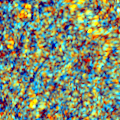

In [ ]:
s1_img

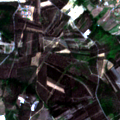

In [ ]:
s2_img

In [ ]:
def build_training_example(row):
    s2_img = render_s2_rgb(row["patch_id"])
    s1_img = render_s1_composite(row["s1_name"])

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": s2_img},
                {"type": "image", "image": s1_img},
                {"type": "text", "text": row["input"]},
            ],
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": row["output"]}],
        },
    ]
    return messages

sample_row = train_rows.iloc[0]
example = build_training_example(sample_row)

# render through the processor's chat template to see the actual text the model will see
text = processor.apply_chat_template(example, tokenize=False, add_generation_prompt=False)
print(text)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|><|vision_start|><|image_pad|><|vision_end|>Is any broad-leaved forest and urban fabrics adjoining regions in this scene?<|im_end|>
<|im_start|>assistant
yes<|im_end|>



/tmp/ipykernel_12527/2210183935.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="RGB")
/tmp/ipykernel_12527/2210183935.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="RGB")


In [ ]:
import os

os.makedirs(f"{PROJECT_DIR}/data/images/s2_rgb", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/data/images/s1_composite", exist_ok=True)

failed_render = []
for i, row in subset.iterrows():
    try:
        s2_path = f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png"
        s1_path = f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png"
        if not os.path.exists(s2_path):
            render_s2_rgb(row["patch_id"]).save(s2_path)
        if not os.path.exists(s1_path):
            render_s1_composite(row["s1_name"]).save(s1_path)
    except Exception as e:
        failed_render.append((row["patch_id"], str(e)))

    if (i + 1) % 1000 == 0:
        print(f"{i+1}/{len(subset)} rendered")

print(f"\nDone. {len(subset) - len(failed_render)} succeeded, {len(failed_render)} failed.")
if failed_render:
    for pid, err in failed_render[:5]:
        print(" ", pid, "-", err)

426000/10000 rendered
263000/10000 rendered
196000/10000 rendered
225000/10000 rendered
116000/10000 rendered
170000/10000 rendered

Done. 10000 succeeded, 0 failed.


In [ ]:
# from torch.utils.data import Dataset
# from PIL import Image

# class SatQueryDataset(Dataset):
#     def __init__(self, qa_df, processor):
#         self.qa_df = qa_df.reset_index(drop=True)
#         self.processor = processor

#     def __len__(self):
#         return len(self.qa_df)

#     def __getitem__(self, idx):
#         row = self.qa_df.iloc[idx]
#         s2_img = Image.open(f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png")
#         s1_img = Image.open(f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png")

#         user_msg = [{
#             "role": "user",
#             "content": [
#                 {"type": "image", "image": s2_img},
#                 {"type": "image", "image": s1_img},
#                 {"type": "text", "text": row["input"]},
#             ],
#         }]
#         full_msg = user_msg + [{
#             "role": "assistant",
#             "content": [{"type": "text", "text": row["output"]}],
#         }]

#         # prompt-only, to find where the response starts (for label masking)
#         prompt_text = self.processor.apply_chat_template(
#             user_msg, tokenize=False, add_generation_prompt=True
#         )
#         full_text = self.processor.apply_chat_template(
#             full_msg, tokenize=False, add_generation_prompt=False
#         )

#         full_inputs = self.processor(
#             text=[full_text], images=[[s2_img, s1_img]],
#             return_tensors="pt", padding=False,
#         )
#         prompt_inputs = self.processor(
#             text=[prompt_text], images=[[s2_img, s1_img]],
#             return_tensors="pt", padding=False,
#         )

#         input_ids = full_inputs["input_ids"][0]
#         prompt_len = prompt_inputs["input_ids"].shape[1]

#         labels = input_ids.clone()
#         labels[:prompt_len] = -100  # mask everything except the assistant's response

#         item = {k: v[0] for k, v in full_inputs.items()}
#         item["labels"] = labels
#         return item
from torch.utils.data import Dataset
from PIL import Image

class SatQueryDataset(Dataset):
    def __init__(self, qa_df, processor):
        self.qa_df = qa_df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.qa_df)

    def __getitem__(self, idx):
        row = self.qa_df.iloc[idx]
        s2_img = Image.open(f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png")
        s1_img = Image.open(f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png")

        user_msg = [{
            "role": "user",
            "content": [
                {"type": "image", "image": s2_img},
                {"type": "image", "image": s1_img},
                {"type": "text", "text": row["input"]},
            ],
        }]
        full_msg = user_msg + [{
            "role": "assistant",
            "content": [{"type": "text", "text": row["output"]}],
        }]

        prompt_text = self.processor.apply_chat_template(
            user_msg, tokenize=False, add_generation_prompt=True
        )
        full_text = self.processor.apply_chat_template(
            full_msg, tokenize=False, add_generation_prompt=False
        )

        full_inputs = self.processor(
            text=[full_text], images=[[s2_img, s1_img]],
            return_tensors="pt", padding=False,
        )
        prompt_inputs = self.processor(
            text=[prompt_text], images=[[s2_img, s1_img]],
            return_tensors="pt", padding=False,
        )

        input_ids = full_inputs["input_ids"][0]
        prompt_len = prompt_inputs["input_ids"].shape[1]

        labels = input_ids.clone()
        labels[:prompt_len] = -100

        per_sequence_keys = {"input_ids", "attention_mask", "mm_token_type_ids"}
        item = {}
        for k, v in full_inputs.items():
            if k in per_sequence_keys:
                item[k] = v[0]
            else:
                item[k] = v
        item["labels"] = labels
        return item

In [ ]:
train_only = train_rows[train_rows["split"] == "train"].reset_index(drop=True)
ds = SatQueryDataset(train_only, processor)

sample = ds[0]
print("input_ids shape:", sample["input_ids"].shape)
print("pixel_values shape:", sample["pixel_values"].shape)
print("image_grid_thw shape:", sample["image_grid_thw"].shape)
print("labels shape:", sample["labels"].shape)
print("Decoded trainable tokens:", processor.tokenizer.decode(sample["labels"][sample["labels"] != -100]))

input_ids shape: torch.Size([77])
pixel_values shape: torch.Size([128, 1176])
image_grid_thw shape: torch.Size([2, 3])
labels shape: torch.Size([77])
Decoded trainable tokens: yes<|im_end|>



In [ ]:


print("Decoded trainable tokens:", processor.tokenizer.decode(sample["labels"][sample["labels"] != -100]))

Decoded trainable tokens: yes<|im_end|>



In [ ]:
import torch

def collate_fn(batch):
    pad_id = processor.tokenizer.pad_token_id or processor.tokenizer.eos_token_id

    per_sequence_keys = ["input_ids", "attention_mask", "labels", "mm_token_type_ids"]
    pad_values = {"input_ids": pad_id, "attention_mask": 0, "labels": -100, "mm_token_type_ids": 0}

    result = {}
    for key in per_sequence_keys:
        if key not in batch[0]:
            continue
        seqs = [item[key] for item in batch]
        max_len = max(s.shape[0] for s in seqs)
        out = torch.full((len(seqs), max_len), pad_values[key], dtype=seqs[0].dtype)
        for i, s in enumerate(seqs):
            out[i, :s.shape[0]] = s
        result[key] = out

    for key in batch[0]:
        if key not in per_sequence_keys:
            result[key] = torch.cat([item[key] for item in batch], dim=0)

    return result

In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(ds, batch_size=2, shuffle=True, collate_fn=collate_fn)
batch = next(iter(loader))
for k, v in batch.items():
    print(k, v.shape if hasattr(v, "shape") else type(v))

input_ids torch.Size([2, 113])
attention_mask torch.Size([2, 113])
labels torch.Size([2, 113])
mm_token_type_ids torch.Size([2, 113])
pixel_values torch.Size([256, 1176])
image_grid_thw torch.Size([4, 3])


In [ ]:
import transformers
print("transformers version:", transformers.__version__)

import inspect
sig = inspect.signature(transformers.TrainingArguments.__init__)
params = list(sig.parameters.keys())
print("\nDoes it have warmup_ratio?", "warmup_ratio" in params)
print("Does it have warmup_steps?", "warmup_steps" in params)
print("\nParams containing 'warmup':", [p for p in params if "warmup" in p.lower()])

transformers version: 5.16.1

Does it have warmup_ratio? False
Does it have warmup_steps? True

Params containing 'warmup': ['warmup_steps']


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
    print("BF16 supported:", torch.cuda.is_bf16_supported())

CUDA available: False


In [21]:
import pandas as pd

subset = pd.read_parquet(os.path.join(PROJECT_DIR, "data", "selected_patches.parquet"))
train_rows = pd.read_parquet(os.path.join(PROJECT_DIR, "data", "selected_qa_rows.parquet"))
train_only = train_rows[train_rows["split"] == "train"].reset_index(drop=True)
print(len(subset), len(train_rows), len(train_only))

10000 213474 109423


In [22]:
N_TRAIN_TARGET = 10_000   # ~3.3h at the measured rate below — raise/lower as your schedule allows

train_only_full = train_only   # keep this around in case you want to scale up later before final submission
if len(train_only_full) > N_TRAIN_TARGET:
    train_only = train_only_full.sample(n=N_TRAIN_TARGET, random_state=42).reset_index(drop=True)

print("Training rows:", len(train_only))
print("\nSampled type distribution:\n", train_only["type"].value_counts(normalize=True))
print("\nFull-set type distribution:\n", train_only_full["type"].value_counts(normalize=True))

Training rows: 10000

Sampled type distribution:
 type
binary          0.3696
mcq             0.3306
bounding box    0.2538
captioning      0.0460
Name: proportion, dtype: float64

Full-set type distribution:
 type
binary          0.369246
mcq             0.333970
bounding box    0.249847
captioning      0.046937
Name: proportion, dtype: float64


In [24]:
from peft import PeftModel

model = PeftModel.from_pretrained(
    base_model,
    os.path.join(PROJECT_DIR, "checkpoints", "qwen2vl-lora", "checkpoint-400"),
    is_trainable=True,
)
model.config.use_cache = False

c:\Users\mayan\Desktop\SIH\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [25]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID, min_pixels=64 * 28 * 28, max_pixels=256 * 28 * 28,
)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, torch_dtype=torch.bfloat16, device_map="auto",
)

for name, param in base_model.named_parameters():
    if name.startswith("visual."):
        param.requires_grad = False

base_model = prepare_model_for_kbit_training(base_model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj", "v_proj"], lora_dropout=0.1, bias="none",
)
model = get_peft_model(base_model, lora_config)
model.config.use_cache = False
model.print_trainable_parameters()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [19]:
from torch.utils.data import Dataset
from PIL import Image

class SatQueryDataset(Dataset):
    def __init__(self, qa_df, processor):
        self.qa_df = qa_df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.qa_df)

    def __getitem__(self, idx):
        row = self.qa_df.iloc[idx]
        s2_img = Image.open(f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png")
        s1_img = Image.open(f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png")

        user_msg = [{
            "role": "user",
            "content": [
                {"type": "image", "image": s2_img},
                {"type": "image", "image": s1_img},
                {"type": "text", "text": row["input"]},
            ],
        }]
        full_msg = user_msg + [{
            "role": "assistant",
            "content": [{"type": "text", "text": row["output"]}],
        }]

        prompt_text = self.processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True)
        full_text = self.processor.apply_chat_template(full_msg, tokenize=False, add_generation_prompt=False)

        full_inputs = self.processor(text=[full_text], images=[[s2_img, s1_img]], return_tensors="pt", padding=False)
        prompt_inputs = self.processor(text=[prompt_text], images=[[s2_img, s1_img]], return_tensors="pt", padding=False)

        input_ids = full_inputs["input_ids"][0]
        prompt_len = prompt_inputs["input_ids"].shape[1]

        labels = input_ids.clone()
        labels[:prompt_len] = -100

        per_sequence_keys = {"input_ids", "attention_mask", "mm_token_type_ids"}
        item = {}
        for k, v in full_inputs.items():
            item[k] = v[0] if k in per_sequence_keys else v
        item["labels"] = labels
        return item

ds = SatQueryDataset(train_only, processor)

AttributeError: 'SatQueryDataset' object has no attribute 'user_msg'

In [27]:
def collate_fn(batch):
    pad_id = processor.tokenizer.pad_token_id or processor.tokenizer.eos_token_id
    per_sequence_keys = ["input_ids", "attention_mask", "labels", "mm_token_type_ids"]
    pad_values = {"input_ids": pad_id, "attention_mask": 0, "labels": -100, "mm_token_type_ids": 0}

    result = {}
    for key in per_sequence_keys:
        if key not in batch[0]:
            continue
        seqs = [item[key] for item in batch]
        max_len = max(s.shape[0] for s in seqs)
        out = torch.full((len(seqs), max_len), pad_values[key], dtype=seqs[0].dtype)
        for i, s in enumerate(seqs):
            out[i, :s.shape[0]] = s
        result[key] = out

    for key in batch[0]:
        if key not in per_sequence_keys:
            result[key] = torch.cat([item[key] for item in batch], dim=0)
    return result

In [28]:
from transformers import TrainingArguments, Trainer

smoke_ds = SatQueryDataset(train_only.iloc[:20], processor)

smoke_args = TrainingArguments(
    output_dir=r"C:\SatQueryAI_local\smoke_test",   # local scratch, not Drive — avoids sync churn
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    num_train_epochs=1,
    logging_steps=1,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    dataloader_num_workers=0,   # >0 workers can hang in a Jupyter kernel on Windows
    remove_unused_columns=False,
    report_to="none",
)

smoke_trainer = Trainer(model=model, args=smoke_args, train_dataset=smoke_ds, data_collator=collate_fn)
smoke_trainer.train()


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
1,0.298817
2,0.174896
3,0.519887
4,0.104800
5,0.047825
6,0.556165
7,0.349696
8,0.312175
9,0.204071
10,0.093975


TrainOutput(global_step=20, training_loss=0.30166442338377236, metrics={'train_runtime': 39.2016, 'train_samples_per_second': 0.51, 'train_steps_per_second': 0.51, 'total_flos': 47953520004096.0, 'train_loss': 0.30166442338377236, 'epoch': 1.0})

In [29]:
import os, json

ckpt_dir = os.path.join(PROJECT_DIR, "checkpoints", "qwen2vl-lora")
print("Exists:", os.path.exists(ckpt_dir))

if os.path.exists(ckpt_dir):
    checkpoints = [d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")]
    print("Found:", checkpoints)
    if checkpoints:
        latest = max(checkpoints, key=lambda d: int(d.split("-")[-1]))
        state_path = os.path.join(ckpt_dir, latest, "trainer_state.json")
        with open(state_path) as f:
            state = json.load(f)
        print("Latest:", latest, "| global_step:", state.get("global_step"), "| epoch:", state.get("epoch"))

Exists: True
Found: ['checkpoint-300', 'checkpoint-350', 'checkpoint-400']
Latest: checkpoint-400 | global_step: 400 | epoch: 0.64


In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 2050


In [30]:
training_args = TrainingArguments(
    output_dir=f"{PROJECT_DIR}/checkpoints/qwen2vl-lora",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_steps=0.03,
    logging_steps=10,
    save_steps=50,              # more granular resume points over ~625 total steps
    save_total_limit=3,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    dataloader_num_workers=0,
    remove_unused_columns=False,
    report_to="none",
)

trainer = Trainer(model=model, args=training_args, train_dataset=ds, data_collator=collate_fn)
trainer.train(resume_from_checkpoint=f"{PROJECT_DIR}/checkpoints/qwen2vl-lora/checkpoint-400")

Step,Training Loss
410,0.515737
420,0.426642
430,0.471008
440,0.489708
450,0.544433
460,0.450997
470,0.512117
480,0.438019
490,0.502578
500,0.459064


TrainOutput(global_step=625, training_loss=0.169041353225708, metrics={'train_runtime': 47539.6135, 'train_samples_per_second': 0.21, 'train_steps_per_second': 0.013, 'total_flos': 2.311276596976435e+16, 'train_loss': 0.169041353225708, 'epoch': 1.0})

In [31]:
final_dir = os.path.join(PROJECT_DIR, "checkpoints", "qwen2vl-lora-final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print("Saved to", final_dir)

Saved to G:\My Drive\SatQueryAI\checkpoints\qwen2vl-lora-final


In [ ]:
!
nvidia-smi

NameError: name 'nvidia' is not defined

In [6]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{PROJECT_DIR}/checkpoints/qwen2vl-lora",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_steps=0.03,
    logging_steps=10,
    save_steps=200,
    save_total_limit=2,
    bf16=True,
    dataloader_num_workers=2,
    remove_unused_columns=False,
    report_to="none",
)
print("TrainingArguments created OK")

W0902 02:23:06.120000 3572 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


TrainingArguments created OK


In [13]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds,
    data_collator=collate_fn,
)

trainer.train()

NameError: name 'ds' is not defined

In [ ]:
smoke_ds = SatQueryDataset(train_only.iloc[:20], processor)

smoke_args = TrainingArguments(
    output_dir="/content/smoke_test",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=1,
    num_train_epochs=1,
    logging_steps=1,
    bf16=True,
    remove_unused_columns=False,
    report_to="none",
)

smoke_trainer = Trainer(
    model=model,
    args=smoke_args,
    train_dataset=smoke_ds,
    data_collator=collate_fn,
)

smoke_trainer.train()

testing

In [ ]:
# Existing notebook cells already define os, torch, pandas, Image, and PeftModel.
# Use the auto class to avoid the broken Qwen2VL lazy import.
from transformers import AutoModelForVision2Seq, AutoProcessor, BitsAndBytesConfig

Qwen2VLForConditionalGeneration = AutoModelForVision2Seq

PROJECT_DIR = r'G:\My Drive\SatQueryAI'
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
FINAL_ADAPTER_DIR = os.path.join(PROJECT_DIR, "checkpoints", "qwen2vl-lora-final")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=64 * 28 * 28, max_pixels=256 * 28 * 28)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, torch_dtype=torch.bfloat16, device_map="auto",
)

model = PeftModel.from_pretrained(base_model, FINAL_ADAPTER_DIR)
model.eval()
model.config.use_cache = True
print("Model reloaded from", FINAL_ADAPTER_DIR)

# rebuild the same 10k training sample (same seed) so the examples line up
train_rows = pd.read_parquet(os.path.join(PROJECT_DIR, "data", "selected_qa_rows.parquet"))
train_only_full = train_rows[train_rows["split"] == "train"].reset_index(drop=True)
train_only = train_only_full.sample(n=10_000, random_state=42).reset_index(drop=True)
print("train_only rows:", len(train_only))

ModuleNotFoundError: Could not import module 'Qwen2VLForConditionalGeneration'. Are this object's requirements defined correctly?

In [ ]:
import torch
from PIL import Image

model.eval()
model.config.use_cache = True   # was off for training, turn back on for generation

def generate_answer(model, processor, s2_img, s1_img, question, max_new_tokens=64):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": s2_img}, {"type": "image", "image": s1_img},
        {"type": "text", "text": question},
    ]}]
    prompt_text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[prompt_text], images=[[s2_img, s1_img]], return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = output_ids[:, inputs["input_ids"].shape[1]:]
    return processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()

for i in range(3):
    row = train_only.iloc[i]
    s2_img = Image.open(f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png")
    s1_img = Image.open(f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png")
    print("Q:", row["input"])
    print("GT:", row["output"])
    print("Pred:", generate_answer(model, processor, s2_img, s1_img, row["input"]))
    print("---")

Q: Show a continuous region of <ref>arable land</ref> in the scene.
GT: [0.0 0.0, 1.0 0.49]
Pred: [0.0 0.0, 0.55 0.85]
---
Q: Are arable lands distributed across at least four separate continuous parts of the image?
GT: no
Pred: no
---
Q: How would you classify the location of the mixed forest in relation to the urban fabric? a) to the left, b) to the top-right, c) to the bottom, d) to the top
GT: c
Pred: c
---


In [17]:
import pandas as pd

held_out = train_rows.merge(
    train_only[["patch_id", "s1_name", "input"]],
    on=["patch_id", "s1_name", "input"],
    how="left",
    indicator=True,
)
held_out = held_out[held_out["_merge"] == "left_only"].drop(columns="_merge")

eval_sample = held_out.sample(n=100, random_state=52).reset_index(drop=True)
print(eval_sample["type"].value_counts())

results = []
failed = []
for _, row in eval_sample.iterrows():
    s2_path = f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png"
    s1_path = f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png"
    try:
        s2_img = Image.open(s2_path); s2_img.load()
        s1_img = Image.open(s1_path); s1_img.load()
        pred = generate_answer(model, processor, s2_img, s1_img, row["input"])
        results.append({"type": row["type"], "q": row["input"], "gt": row["output"], "pred": pred})
    except Exception as e:
        failed.append((row["patch_id"], row["s1_name"], str(e)))

print(f"Succeeded: {len(results)}, Failed: {len(failed)}")
for pid, sid, err in failed[:5]:
    print(" ", pid, sid, "-", err)

results_df = pd.DataFrame(results)
results_df.head(10)

type
binary          35
mcq             32
bounding box    25
captioning       8
Name: count, dtype: int64
Succeeded: 100, Failed: 0


,type,q,gt,pred
0,binary,Is the surface of arable lands not greater tha...,yes,yes
1,mcq,Which of the following climate zones is captur...,c,c
2,mcq,"Identify touching classes: a) Beaches, dunes, ...",c,b
3,bounding box,Provide a bounding box enclosing the land cove...,"[0.43 0.0, 0.6 0.1]","[0.0 0.0, 1.0 0.1]"
4,bounding box,Create a bounding box around the land cover cl...,"[0.5 0.14, 1.0 1.0]","[0.6 0.3, 1.0 1.0]"
5,bounding box,Provide a bounding box around the land cover c...,"[0.66 0.87, 0.97 1.0]","[0.55 0.87, 1.0 1.0]"
6,mcq,What is the total area of mixed forests in the...,d,a
7,mcq,Identify the number of continuous areas of lan...,c,c
8,mcq,"Identify the season, in which the satellite im...",c,a
9,binary,Do mixed forests occupy between 0% and 20% of ...,yes,yes


In [ ]:
import re

def normalize(s):
    return str(s).strip().lower().rstrip(".")

def parse_box(s):
    nums = re.findall(r"[-+]?\d*\.?\d+", str(s))
    if len(nums) < 4:
        return None
    x1, y1, x2, y2 = map(float, nums[:4])
    return (x1, y1, x2, y2)

def iou(box_a, box_b):
    if box_a is None or box_b is None:
        return 0.0
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

# Binary + MCQ
closed = results_df[results_df["type"].isin(["binary", "mcq"])].copy()
closed["correct"] = closed.apply(lambda r: normalize(r["gt"]) == normalize(r["pred"]), axis=1)
print("=== Binary + MCQ ===")
print("Overall accuracy:", closed["correct"].mean(), f"(n={len(closed)})")
print(closed.groupby("type")["correct"].mean())

# Bounding box
boxes = results_df[results_df["type"] == "bounding box"].copy()
boxes["iou"] = boxes.apply(lambda r: iou(parse_box(r["gt"]), parse_box(r["pred"])), axis=1)
print("\n=== Bounding Box ===")
print("Mean IoU:", boxes["iou"].mean(), f"(n={len(boxes)})")
print("Fraction with IoU > 0.5:", (boxes["iou"] > 0.5).mean())

# Captioning - eyeball these, no simple auto-metric
print("\n=== Captioning samples ===")
for _, r in results_df[results_df["type"] == "captioning"].head(5).iterrows():
    print("Q:", r["q"], "\nGT:", r["gt"], "\nPred:", r["pred"], "\n---")

=== Binary + MCQ ===
Overall accuracy: 0.6417910447761194 (n=67)
type
binary    0.685714
mcq       0.593750
Name: correct, dtype: float64

=== Bounding Box ===
Mean IoU: 0.3967608605872765 (n=25)
Fraction with IoU > 0.5: 0.44

=== Captioning samples ===
Q: Describe the image, specifying the region, climate, and landscape features. 
GT: This satellite image, captured during the spring season in Luxembourg, showcases a diverse landscape within the "temperate, no dry season, warm summer" climate zone. The dominant feature is the expansive coniferous forest, covering approximately 594,000 square meters, which shares borders with both mixed forest, spanning around 432,000 square meters, and complex cultivation patterns, covering about 415,000 square meters. The mixed forest, which is distributed across two smaller areas of 343,000 square meters and 89,000 square meters, is also adjacent to the complex cultivation patterns, suggesting a dynamic interplay between forested and agricultural are

train_only rows: 10000


In [8]:
# Pick any test image

row = test_rows.iloc[1500]
print (row)
s2_img = Image.open(
    f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png"
).convert("RGB")

s1_img = Image.open(
    f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png"
).convert("RGB")


# YOUR CUSTOM QUESTION
custom_question = "I have provided you two satellite images of same place , one of them is optical image and one is sar image .What land-cover types are visible in the optical and SAR images? "


# Generate answer
prediction = generate_answer(
    model,
    processor,
    s2_img,
    s1_img,
    custom_question
)


# Show images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(s2_img)
plt.title("Sentinel-2 Optical")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(s1_img)
plt.title("Sentinel-1 SAR")
plt.axis("off")

plt.show()


# Show question + answer
print("QUESTION:")
print(custom_question)

print("\nMODEL ANSWER:")
print(prediction)

NameError: name 'test_rows' is not defined

In [2]:
!pip install -q matplotlib

In [9]:
%pip install matplotlib
import matplotlib.pyplot as plt
import torch
from PIL import Image

model.eval()
model.config.use_cache = True


def generate_answer(model, processor, s2_img, s1_img, question, max_new_tokens=64):

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": s2_img},
            {"type": "image", "image": s1_img},
            {"type": "text", "text": question},
        ]
    }]

    prompt_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[prompt_text],
        images=[[s2_img, s1_img]],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    # Remove the input/prompt tokens
    trimmed = output_ids[:, inputs["input_ids"].shape[1]:]

    answer = processor.batch_decode(
        trimmed,
        skip_special_tokens=True
    )[0].strip()

    return answer


# Make sure we are testing the TEST split
test_rows = train_rows[
    train_rows["split"] == "test"
].reset_index(drop=True)


# Show 3 test examples
for i in range(3):

    row = test_rows.iloc[i]

    # Load images
    s2_path = f"{PROJECT_DIR}/data/images/s2_rgb/{row['patch_id']}.png"
    s1_path = f"{PROJECT_DIR}/data/images/s1_composite/{row['s1_name']}.png"

    s2_img = Image.open(s2_path).convert("RGB")
    s1_img = Image.open(s1_path).convert("RGB")

    # Generate prediction
    prediction = generate_answer(
        model,
        processor,
        s2_img,
        s1_img,
        row["input"]
    )

    # Display images
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(s2_img)
    plt.title("Sentinel-2 Optical")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(s1_img)
    plt.title("Sentinel-1 SAR")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Display results
    print("=" * 70)
    print(f"TEST SAMPLE {i + 1}")
    print(f"Patch ID: {row['patch_id']}")
    print(f"Type: {row.get('type', 'N/A')}")
    print()
    print("QUESTION:")
    print(row["input"])
    print()
    print("GROUND TRUTH:")
    print(row["output"])
    print()
    print("MODEL PREDICTION:")
    print(prediction)
    print("=" * 70)

Note: you may need to restart the kernel to use updated packages.


NameError: name 'model' is not defined

In [3]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

MODEL_PATH = r"G:\My Drive\SatQueryAI\checkpoints\qwen2vl-merged-final"

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(
    MODEL_PATH
)

print("Model loaded successfully!")

W0906 16:43:49.016000 22772 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
%pip install matplotlib
import matplotlib.pyplot as plt
import torch
from PIL import Image

model.eval()
model.config.use_cache = True


def generate_answer(model, processor, s2_img, s1_img, question, max_new_tokens=64):

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": s2_img},
            {"type": "image", "image": s1_img},
            {"type": "text", "text": question},
        ]
    }]

    prompt_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[prompt_text],
        images=[[s2_img, s1_img]],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    # Remove the input/prompt tokens
    trimmed = output_ids[:, inputs["input_ids"].shape[1]:]

    answer = processor.batch_decode(
        trimmed,
        skip_special_tokens=True
    )[0].strip()

    return answer

img1=Image.open(r"C:\Users\mayan\Pictures\optical1.png").convert("RGB")
img2=Image.open(r"C:\Users\mayan\Pictures\sar1.png").convert("RGB")
result = generate_answer(model, processor, img1, img2, "What land-cover types are visible in the optical and SAR images?")
print("Model Prediction:", result)

Note: you may need to restart the kernel to use updated packages.
Model Prediction: The optical image shows a mix of agricultural land, urban areas, and natural vegetation. The SAR image shows a large body of water, which is also a part of the agricultural land.


In [7]:
from huggingface_hub import login, upload_large_folder

login()

upload_large_folder(
    repo_id="manny2706/satquery-qwen2vl-4bitQuantized",
    folder_path=r"G:\My Drive\SatQueryAI\checkpoints\qwen2vl-merged-final",
    repo_type="model"
)

C:\Users\mayan\AppData\Local\Temp\ipykernel_22772\1386674195.py:5: FutureWarning: 
`upload_large_folder` is DEPRECATED and will be removed in a future release.

Use `upload_folder` instead:

    api.upload_folder(repo_id="manny2706/satquery-qwen2vl-4bitQuantized", repo_type="model", folder_path="G:\My Drive\SatQueryAI\checkpoints\qwen2vl-merged-final")

  upload_large_folder(


Recovering from metadata files:   0%|          | 0/8 [00:00<?, ?it/s]




---------- 2026-09-06 16:49:57 (0:00:00) ----------
Files:   hashed 0/8 (0.0/1.5G) | pre-uploaded: 0/0 (0.0/1.5G) (+8 unsure) | committed: 0/8 (0.0/1.5G) | ignored: 0
Workers: hashing: 6 | get upload mode: 0 | pre-uploading: 0 | committing: 0 | waiting: 0
---------------------------------------------------


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


---------- 2026-09-06 16:50:57 (0:01:00) ----------
Files:   hashed 8/8 (1.5G/1.5G) | pre-uploaded: 1/2 (11.4M/1.5G) | committed: 0/8 (0.0/1.5G) | ignored: 0
Workers: hashing: 0 | get upload mode: 0 | pre-uploading: 1 | committing: 0 | waiting: 5
---------------------------------------------------
                       
---------- 2026-09-06 16:51:57 (0:02:00) ----------
Files:   hashed 8/8 (1.5G/1.5G) | pre-uploaded: 1/2 (11.4M/1.5G) | committed: 0/8 (0.0/1.5G) | ignored: 0
Workers: hashing: 0 | get upload mode: 0 | pre-uploading: 1 | committing: 0 | waiting: 5
---------------------------------------------------
                       
---------- 2026-09-06 16:52:58 (0:03:00) ----------
Files:   hashed 8/8 (1.5G/1.5G) | pre-uploaded: 1/2 (11.4M/1.5G) | committed: 0/8 (0.0/1.5G) | ignored: 0
Workers: hashing: 0 | get upload mode: 0 | pre-uploading: 1 | committing: 0 | waiting: 5
---------------------------------------------------
                       
---------- 2026-09-06 16:53:58